In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [11]:
from google.colab import files
uploaded = files.upload()

Saving Archive.zip to Archive (1).zip


In [2]:
base_dir = "chest_xray"

train_dir = base_dir + "/train"
val_dir = base_dir + "/val"
test_dir = base_dir + "/test"

In [15]:
import zipfile
import os
import shutil

base_dir = "chest_xray"

# Check if the base_dir exists, if not, try to unzip Archive (1).zip
if not os.path.exists(base_dir):
    if os.path.exists('Archive (1).zip'):
        print(f"'{base_dir}' not found. Attempting to unzip 'Archive (1).zip'...")
        with zipfile.ZipFile('Archive (1).zip', 'r') as zip_ref:
            zip_ref.extractall('.')

        # After extraction, check if 'chest_xray' was created directly
        if os.path.exists(base_dir):
            print(f"Successfully unzipped 'Archive (1).zip' to create '{base_dir}'.")
        else:
            # If 'chest_xray' was not created, check if 'train', 'val', 'test' exist directly
            if os.path.exists('train') and os.path.exists('val') and os.path.exists('test'):
                print(f"'{base_dir}' not found directly after unzipping, but 'train', 'val', 'test' directories found. Moving them to '{base_dir}'.")
                os.makedirs(base_dir, exist_ok=True)
                shutil.move('train', os.path.join(base_dir, 'train'))
                shutil.move('val', os.path.join(base_dir, 'val'))
                shutil.move('test', os.path.join(base_dir, 'test'))
                print(f"Successfully organized data into '{base_dir}'.")
            else:
                print(f"Error: Failed to create '{base_dir}' after unzipping, and expected subdirectories ('train', 'val', 'test') not found in the current directory. Please check the contents of 'Archive (1).zip'.")
    else:
        print("Error: 'chest_xray' directory not found and 'Archive (1).zip' is also missing. Please upload the dataset.")

train_data = ImageDataGenerator(rescale=1./255)

train_generator = train_data.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_generator = train_data.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

'chest_xray' not found. Attempting to unzip 'Archive (1).zip'...
'chest_xray' not found directly after unzipping, but 'train', 'val', 'test' directories found. Moving them to 'chest_xray'.
Successfully organized data into 'chest_xray'.
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [8]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history = model.fit(train_generator,epochs=5,validation_data=val_generator)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.8993 - loss: 0.3091 - val_accuracy: 0.8750 - val_loss: 0.3126
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.9636 - loss: 0.1014 - val_accuracy: 0.8125 - val_loss: 0.4054
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.9762 - loss: 0.0708 - val_accuracy: 1.0000 - val_loss: 0.0869
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.9768 - loss: 0.0642 - val_accuracy: 0.8125 - val_loss: 0.5468
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.9841 - loss: 0.0434 - val_accuracy: 0.9375 - val_loss: 0.1218


In [17]:
test_generator = train_data.flow_from_directory(test_dir,target_size=(150,150),batch_size=32,class_mode='binary')

loss, acc = model.evaluate(test_generator)
print("Accuracy:", acc)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 561ms/step - accuracy: 0.7724 - loss: 0.9361
Accuracy: 0.7724359035491943


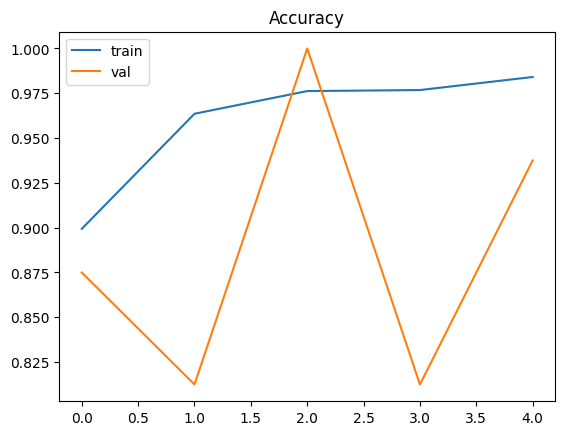

In [18]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()